# 🍎 Clasificación de Frutas con Redes Neuronales Convolucionales
## Universidad Tecnológica Nacional – Regional Rosario

> Notebook acotado a la **Etapa 2**: dataset realista *UTN-IA 2026 · Food Classification - Training Set*.


## Celda 0: Configuración del entorno

In [1]:
import torch

# Detectar dispositivo: CUDA (NVIDIA/Colab) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Dispositivo: GPU NVIDIA – {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Dispositivo: Apple Silicon (MPS) – GPU Metal-accelerada')
else:
    device = torch.device('cpu')
    print('Dispositivo: CPU (no se detectó GPU)')

# Aprovechar todos los núcleos de CPU del M5 para ops que corren ahí
torch.set_num_threads(8)
print(f'Threads CPU: {torch.get_num_threads()}')


Dispositivo: Apple Silicon (MPS) – GPU Metal-accelerada
Threads CPU: 8


In [2]:
# Instalar dependencias adicionales
#!pip install -q kaggle scikit-learn seaborn

import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from utils import cargar_imagen_limpia
from dotenv import load_dotenv

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
elif torch.backends.mps.is_available(): torch.mps.manual_seed(SEED)

print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')
print('✅ Librerías importadas')


PyTorch 2.13.0 | Torchvision 0.28.0
✅ Librerías importadas


---
# 🍓 ETAPA 2: Dataset UTN-IA 2026
## El desafío de generalización

Usamos el mismo modelo con un dataset con fondos variables e iluminación real.
El modelo obtendrá **peor desempeño**. Esta es la lección más importante:

> **El dataset determina tanto o más que la arquitectura.**

**Dataset:** UTN-IA 2026 · Food Classification - Training Set  
**Link:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set  
**Licencia:** Apache 2.0

> ⚠️ Las imágenes tienen fondos variados e iluminación real: la distribución del dataset impacta fuertemente el rendimiento del modelo.


### Descarga del dataset

Para descargar desde Kaggle necesitás una API key:
1. Ir a kaggle.com → tu perfil → Settings → API → Create New Token
2. Copiar `API TOKEN`
3. Pegarlo en la celda de abajo


In [3]:
# Cargar credenciales desde .env (ignorado por git)
from dotenv import load_dotenv
load_dotenv()

os.environ.setdefault("KAGGLE_API_TOKEN", "")  # se setea vía load_dotenv
token = os.environ.get("KAGGLE_API_TOKEN")
if not token:
    raise RuntimeError("Falta KAGGLE_API_TOKEN en .env (ver .env.example)")
print("🔑 Token Kaggle cargado desde .env")


🔑 Token Kaggle cargado desde .env


In [4]:
!kaggle datasets download -d geronimoforconi/utn-ia-2026-food-classification-training-set \
    -p ./data/fruit_recognition --unzip -q
print("✅ Dataset UTN-IA 2026 descargado")

raiz_r = Path("./data/fruit_recognition")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set
License(s): apache-2.0
✅ Dataset UTN-IA 2026 descargado


### Hiperparámetros y transformación base (val/test)

In [5]:
IMG_SIZE   = 64
BATCH_SIZE = 64
NUM_CLASES = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Pipeline base: val y test (sin augmentation)
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print('✅ Hiperparámetros + transform_base definidos (val/test)')
print('   Train usa un pipeline con augmentation (ver celda siguiente)')


✅ Hiperparámetros + transform_base definidos (val/test)
   Train usa un pipeline con augmentation (ver celda siguiente)


### Arquitectura de la CNN

In [6]:
class FrutasCNN(nn.Module):
    """
    CNN para clasificación de frutas.
    Cada bloque duplica filtros (32->64->128) y reduce tamaño espacial con MaxPool.
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # Bloque 1: detecta bordes y texturas simples
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 canales RGB -> 32 mapas
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64x64 -> 32x32
        )
        # Bloque 2: detecta combinaciones de bordes
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32x32 -> 16x16
        )
        # Bloque 3: detecta representaciones complejas
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16x16 -> 8x8
        )
        # Clasificador final
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),   # Regularización contra overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        return self.clasificador(x)


### Funciones de entrenamiento y evaluación

In [7]:
EPOCHS = 100
LR     = 1e-3

criterion = nn.CrossEntropyLoss()

def entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        # AMP (mixed precision): acelera forward en MPS
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

@torch.no_grad()
def evaluar(model, loader, criterion, device):
    model.eval()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total


#### Helpers de visualización

In [8]:
def analizar_distribucion(base_dir):
    splits = ['train', 'val', 'test']
    conteos = {s: {} for s in splits}
    for s in splits:
        sd = base_dir / s
        if sd.exists():
            for c in os.listdir(sd):
                conteos[s][c] = len(list((sd/c).glob('*.jpg')))

    clases = list(conteos['train'].keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(clases)); w = 0.25
    for idx, (s, col) in enumerate(zip(splits, ['#2196F3','#4CAF50','#FF9800'])):
        ax1.bar(x + idx*w, [conteos[s].get(c,0) for c in clases], w, label=s, color=col, alpha=0.85)
    ax1.set_xticks(x+w); ax1.set_xticklabels([c.split()[0] for c in clases], rotation=15)
    ax1.set_title('Distribución por clase y split'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

    totales = {c: sum(conteos[s].get(c,0) for s in splits) for c in clases}
    ax2.pie(totales.values(), labels=[c.split()[0] for c in clases], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribución total')
    plt.tight_layout(); plt.show()

    print(f'{"Clase":<22} {"Train":>8} {"Val":>8} {"Test":>8}')
    print('-'*50)
    for c in clases:
        print(f'{c:<22} {conteos["train"].get(c,0):>8} {conteos["val"].get(c,0):>8} {conteos["test"].get(c,0):>8}')


In [9]:
def graficar_historial(hist, titulo='Etapa 2 – Food Classification'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(hist['train_loss'])+1)
    ax1.plot(ep, hist['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(ep, hist['val_loss'],   'r-o', ms=3, label='Val')
    ax1.axvline(x=np.argmin(hist['val_loss'])+1, color='gray', ls='--', alpha=0.7)
    ax1.set_title('Curvas de Pérdida'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [a*100 for a in hist['train_acc']], 'b-o', ms=3, label='Train')
    ax2.plot(ep, [a*100 for a in hist['val_acc']],   'r-o', ms=3, label='Val')
    ax2.set_title('Curvas de Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim([0,105])
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(f'Historial de Entrenamiento – {titulo}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Mejor Val Accuracy: {max(hist["val_acc"])*100:.2f}% (epoch {np.argmax(hist["val_acc"])+1})')


### Helpers de evaluación (matriz de confusión + F1)

In [10]:
@torch.no_grad()
def obtener_predicciones(model, loader, device):
    """Corre el modelo sobre un loader y devuelve (preds, labels) como arrays numpy."""
    model.eval()
    preds_all, labels_all = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        _, preds = out.max(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)


def graficar_confusion(preds, labels, class_names, titulo='Confusión'):
    """Plotea matriz de confusión cruda + normalizada (recall por clase)."""
    nombres = [c.split()[0] for c in class_names]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax1)
    ax1.set_title('Conteos'); ax1.set_xlabel('Predicho'); ax1.set_ylabel('Real')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax2)
    ax2.set_title('Normalizado (recall)'); ax2.set_xlabel('Predicho'); ax2.set_ylabel('Real')
    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def graficar_reporte(preds, labels, class_names):
    """Imprime classification_report + F1 weighted (métrica oficial de la competencia)."""
    print(classification_report(labels, preds, target_names=class_names))
    f1w = f1_score(labels, preds, average='weighted')
    print(f"🎯 F1 weighted (métrica oficial): {f1w:.4f}")


def visualizar_errores(model, loader, class_names, device, n=16):
    """Muestra las primeras n imágenes mal clasificadas con etiqueta real vs. predicha."""
    model.eval()
    mostradas = 0
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    with torch.no_grad():
        for imgs_b, labels_b in loader:
            imgs_d = imgs_b.to(device)
            _, preds = model(imgs_d).max(1)
            preds = preds.cpu()
            for i in range(len(imgs_b)):
                if preds[i] != labels_b[i] and mostradas < n:
                    img = imgs_b[i] * std + mean
                    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
                    axes[mostradas].imshow(img)
                    axes[mostradas].axis('off')
                    real = class_names[labels_b[i]]
                    pred = class_names[preds[i]]
                    axes[mostradas].set_title(
                        f"Real: {real}\nPred: {pred}", fontsize=9, color='red'
                    )
                    mostradas += 1
            if mostradas >= n:
                break
    for j in range(mostradas, len(axes)):
        axes[j].axis('off')
    plt.suptitle('Imágenes mal clasificadas', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()



## Etapa 2: UTN-IA 2026 · Food Classification - Training Set

In [11]:
# ============================================================
# Etapa 2: UTN-IA 2026 · Food Classification - Training Set
# El dataset tiene solo imágenes de train → dividimos en train/val/test
# ============================================================
import shutil, random
from pathlib import Path

RAIZ_FOOD = Path('./data/fruit_recognition')
BASE_DIR_R = Path('./data/fruit_recognition_splint/')
CLASES_R   = ['apple', 'banana', 'grapes', 'potato', 'tomato']

# Proporciones del split (deben sumar 1.0)
SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.15
SPLIT_TEST  = 0.15

def crear_subset_desde_train(clases, raiz, destino, split_train=0.70, split_val=0.15):
    # Limpiar split previo (evita duplicados al re-ejecutar)
    if destino.exists():
        shutil.rmtree(destino, ignore_errors=True)

    """
    Busca imágenes bajo raiz/<clase>/ o raiz/train/<clase>/,
    hace split estratificado y copia a destino/train|val|test/<clase>/.
    """
    # Detectar si las clases están directamente o bajo una subcarpeta 'train/'
    probe = raiz / clases[0]
    src_base = raiz if probe.exists() else raiz / 'train'

    for clase in clases:
        imgs = sorted([
            p for p in (src_base / clase).glob('**/*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])
        if not imgs:
            print(f'⚠️  Sin imágenes para clase "{clase}" en {src_base}')
            continue

        random.shuffle(imgs)
        n = len(imgs)
        n_val  = int(n * split_val)
        n_test = int(n * (1 - split_train - split_val))

        splits = {
            'val':   imgs[:n_val],
            'test':  imgs[n_val:n_val + n_test],
            'train': imgs[n_val + n_test:],
        }

        for split_name, subset in splits.items():
            dst = destino / split_name / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in subset:
                shutil.copy(img, dst / img.name)

        print(f'  {clase}: {len(splits["train"])} train | {len(splits["val"])} val | {len(splits["test"])} test')

    print(f'\n✅ Split creado en {destino}')

crear_subset_desde_train(CLASES_R, RAIZ_FOOD, BASE_DIR_R, SPLIT_TRAIN, SPLIT_VAL)

  apple: 39 train | 7 val | 7 test
  banana: 42 train | 9 val | 9 test
  grapes: 56 train | 11 val | 11 test
  potato: 44 train | 9 val | 9 test
  tomato: 52 train | 10 val | 10 test

✅ Split creado en data/fruit_recognition_splint


## Visualización de ejemplos del dataset realista

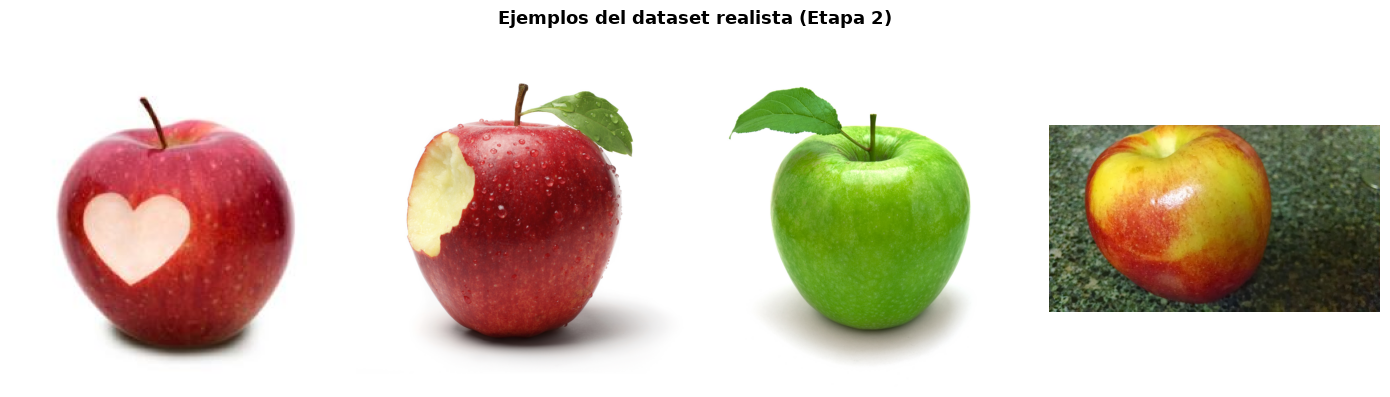

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
base = BASE_DIR_R
clase = CLASES_R[0]
carpeta = base / 'train' / clase
imgs = list(carpeta.glob('*.jpg'))[:4] or list(carpeta.glob('*.png'))[:4]
for col, img_path in enumerate(imgs[:4]):
    axes[col].imshow(Image.open(img_path))
    axes[col].axis('off')
    if col == 0:
        axes[col].set_ylabel('Dataset Realista', fontsize=10, fontweight='bold')
plt.suptitle('Ejemplos del dataset realista (Etapa 2)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Augmentation

In [13]:
# Augmentation más agresivo para el dataset realista (pocos datos, más variabilidad)
transform_train_r = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

train_r = ImageFolder(str(BASE_DIR_R/'train'), transform=transform_train_r,
                      loader=cargar_imagen_limpia)
val_r   = ImageFolder(str(BASE_DIR_R/'val'),   transform=transform_base,
                      loader=cargar_imagen_limpia)
test_r  = ImageFolder(str(BASE_DIR_R/'test'),  transform=transform_base,
                      loader=cargar_imagen_limpia)

train_loader_r = DataLoader(train_r, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=6, persistent_workers=True, prefetch_factor=4, pin_memory=False)
val_loader_r   = DataLoader(val_r,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)
test_loader_r  = DataLoader(test_r,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)

class_names_r = train_r.classes
print(f'✅ Dataset realista: train={len(train_r)} | val={len(val_r)} | test={len(test_r)}')


✅ Dataset realista: train=233 | val=46 | test=46


## Entrenar el MISMO modelo en el dataset realista


In [14]:
# Asegurar directorios locales necesarios
Path('./data').mkdir(parents=True, exist_ok=True)
Path('./checkpoints').mkdir(parents=True, exist_ok=True)
print('✅ Directorios data/ y checkpoints/ listos')


✅ Directorios data/ y checkpoints/ listos


In [15]:
modelo_r = FrutasCNN(num_classes=len(class_names_r)).to(device)
optimizer_r = optim.Adam(modelo_r.parameters(), lr=1e-3, weight_decay=1e-3)  # mayor regularización
scheduler_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_r, patience=5, factor=0.5)

historial_r = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_r = float('inf'); CKPT_R = './checkpoints/mejor_modelo_realista.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-'*58)

for epoch in range(1, EPOCHS+1):
    tl, ta = entrenar_epoch(modelo_r, train_loader_r, criterion, optimizer_r, device)
    vl, va = evaluar(modelo_r, val_loader_r, criterion, device)
    scheduler_r.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial_r[k].append(v)
    marca = ''
    if vl < mejor_r:
        mejor_r = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r.state_dict(), 'val_acc':va}, CKPT_R)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     5.0115 |     18.9% |     1.6415 |     32.6% ✅
     2 |     2.8478 |     26.6% |     1.1803 |     54.3% ✅
     3 |     1.9678 |     42.9% |     1.2357 |     56.5%
     4 |     1.4032 |     45.5% |     1.1349 |     54.3% ✅
     5 |     1.5901 |     39.5% |     1.1929 |     58.7%
     6 |     1.2670 |     48.1% |     1.1903 |     65.2%
     7 |     1.3817 |     40.3% |     1.1882 |     60.9%
     8 |     1.2619 |     47.6% |     1.1415 |     69.6%
     9 |     1.3025 |     45.1% |     1.1160 |     65.2% ✅
    10 |     1.2803 |     45.9% |     1.0960 |     65.2% ✅
    11 |     1.2875 |     48.9% |     1.1070 |     71.7%
    12 |     1.2330 |     50.2% |     1.1327 |     67.4%
    13 |     1.2585 |     48.9% |     1.1310 |     65.2%
    14 |     1.2823 |     45.1% |     1.1323 |     65.2%
    15 |     1.1845 |     51.1% |     1.0412 |     71.7% ✅
    16 |     1.

## 📊 Evaluación del mejor modelo

Cargamos el **mejor epoch** (según val_loss) y evaluamos:
- Matriz de confusión sobre **val** y **test**
- `classification_report` + **F1 weighted** (métrica oficial de la competencia)
- Visualización de las primeras imágenes mal clasificadas


🏆 Mejor epoch: 83 | Val acc: 78.26%

VALIDACIÓN


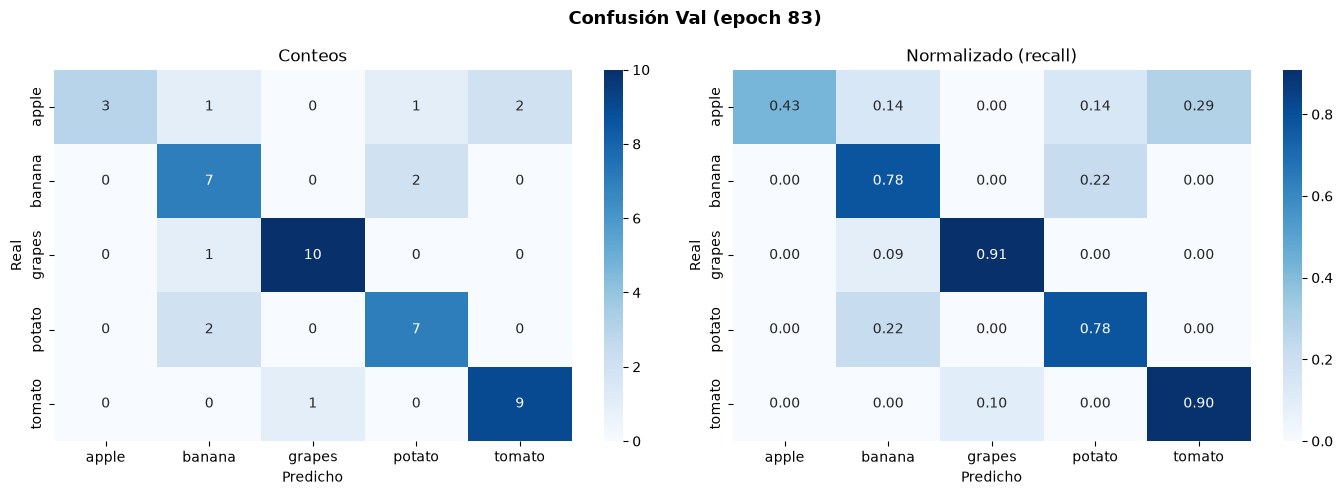

              precision    recall  f1-score   support

       apple       1.00      0.43      0.60         7
      banana       0.64      0.78      0.70         9
      grapes       0.91      0.91      0.91        11
      potato       0.70      0.78      0.74         9
      tomato       0.82      0.90      0.86        10

    accuracy                           0.78        46
   macro avg       0.81      0.76      0.76        46
weighted avg       0.81      0.78      0.78        46

🎯 F1 weighted (métrica oficial): 0.7762

TEST


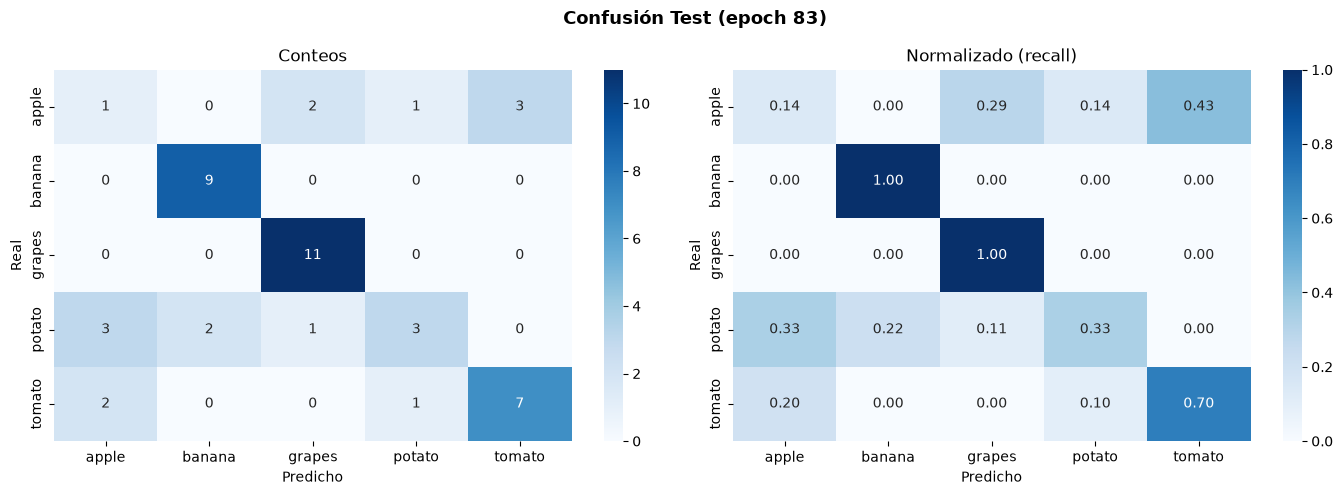

              precision    recall  f1-score   support

       apple       0.17      0.14      0.15         7
      banana       0.82      1.00      0.90         9
      grapes       0.79      1.00      0.88        11
      potato       0.60      0.33      0.43         9
      tomato       0.70      0.70      0.70        10

    accuracy                           0.67        46
   macro avg       0.61      0.64      0.61        46
weighted avg       0.64      0.67      0.65        46

🎯 F1 weighted (métrica oficial): 0.6460

--- Errores visuales (val) ---


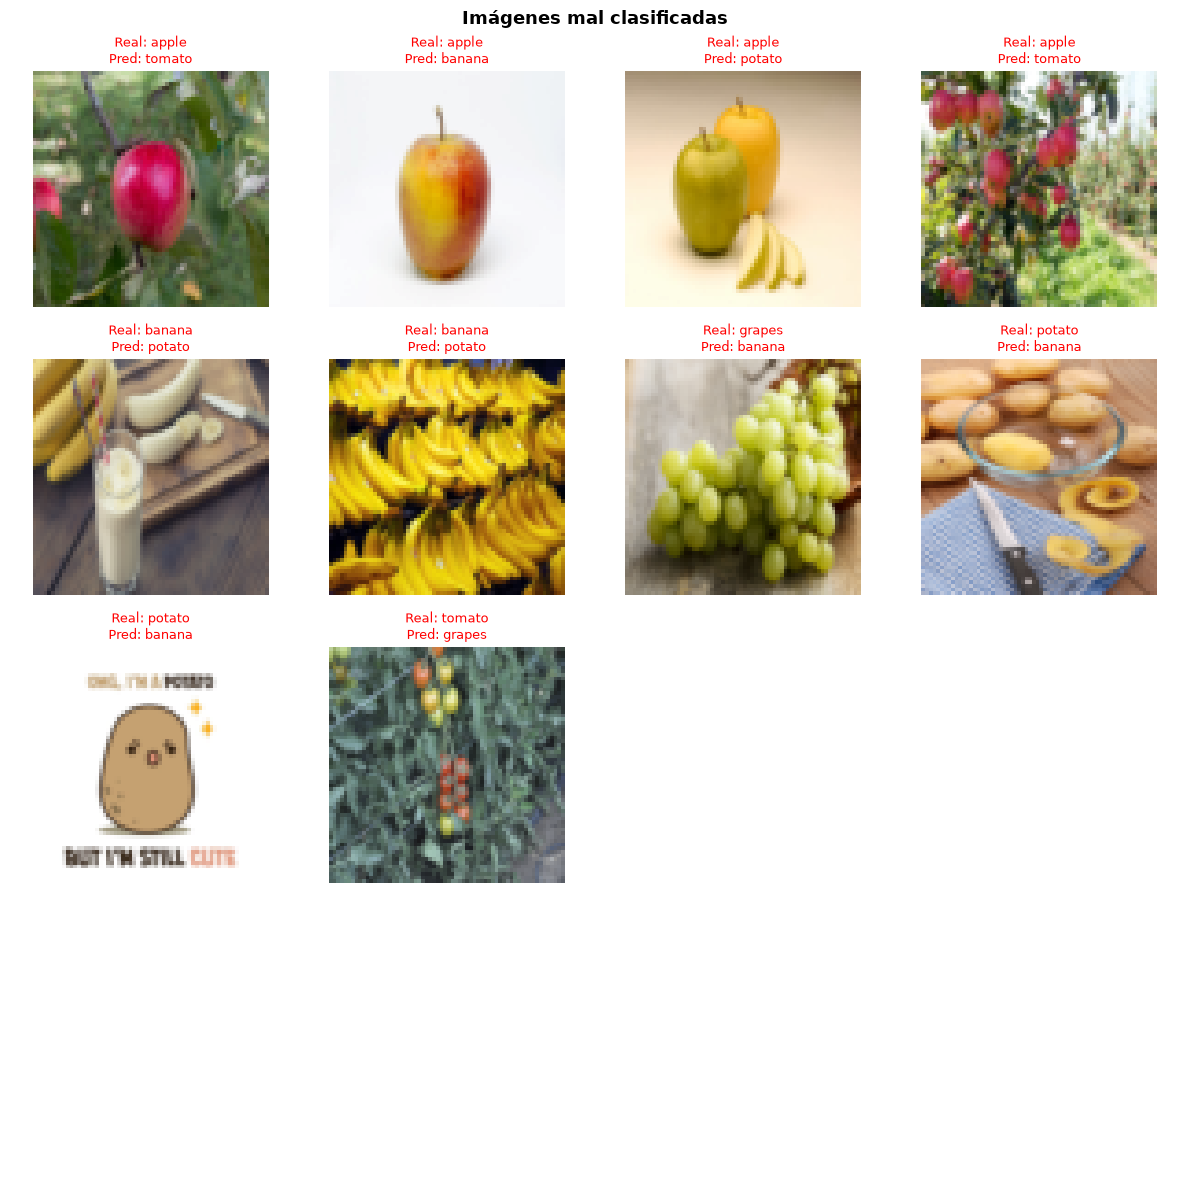

In [16]:
# === Evaluación del mejor epoch ===
ckpt = torch.load(CKPT_R, map_location=device)
modelo_r.load_state_dict(ckpt['model_state_dict'])
print(f"🏆 Mejor epoch: {ckpt['epoch']} | Val acc: {ckpt['val_acc']:.2%}")

print("\n" + "="*60)
print("VALIDACIÓN")
print("="*60)
preds_v, labels_v = obtener_predicciones(modelo_r, val_loader_r, device)
graficar_confusion(preds_v, labels_v, class_names_r,
                   titulo=f'Confusión Val (epoch {ckpt["epoch"]})')
graficar_reporte(preds_v, labels_v, class_names_r)

print("\n" + "="*60)
print("TEST")
print("="*60)
preds_t, labels_t = obtener_predicciones(modelo_r, test_loader_r, device)
graficar_confusion(preds_t, labels_t, class_names_r,
                   titulo=f'Confusión Test (epoch {ckpt["epoch"]})')
graficar_reporte(preds_t, labels_t, class_names_r)

print("\n--- Errores visuales (val) ---")
visualizar_errores(modelo_r, val_loader_r, class_names_r, device, n=16)


## Curvas de aprendizaje (Etapa 2)

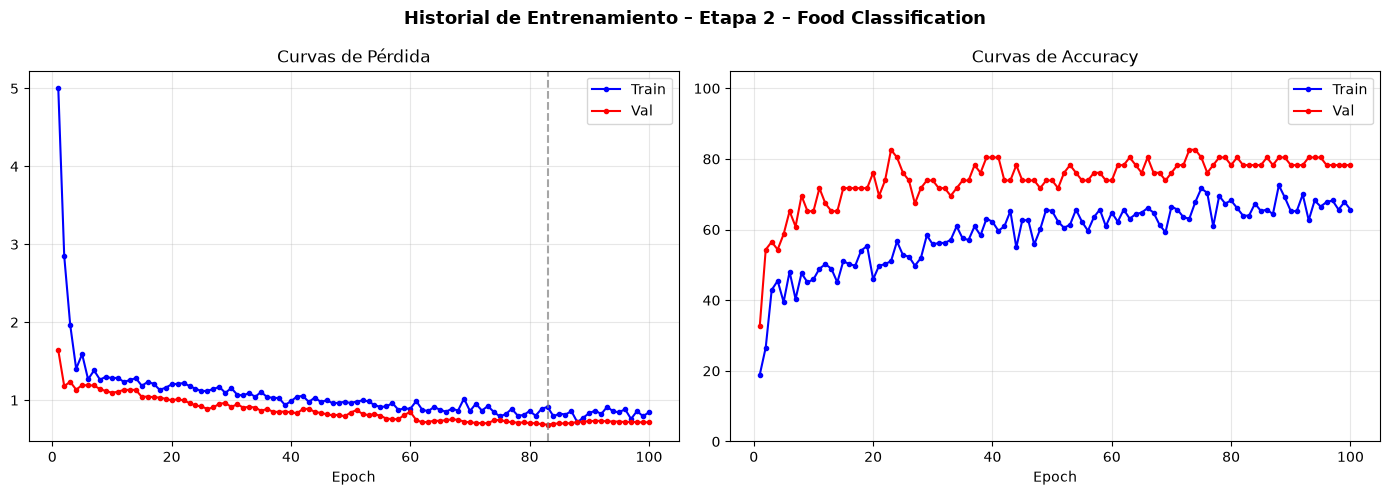

Mejor Val Accuracy: 82.61% (epoch 23)


In [17]:
graficar_historial(historial_r, titulo='Etapa 2 – Food Classification')


---
# 🚀 Mejora del modelo: Transfer Learning con ResNet18

El baseline con `FrutasCNN` (entrenada desde cero sobre 233 imágenes) **no tiene chance** contra un modelo pre-entrenado sobre millones de imágenes (ImageNet).

**Estrategia (2 etapas):**
1. **Freeze** del backbone (todas las capas convolucionales congeladas) → entrenar __solo__ la capa `fc` nueva durante ~10 epochs con LR=1e-3.
2. **Unfreeze** completo → fine-tune de toda la red con LR __muy bajo__ (1e-5) durante ~25 epochs. Usamos `CosineAnnealingLR` como scheduler.

ResNet18 espera entradas **224×224**, así que creamos nuevos transforms y loaders con ese tamaño.


## 1. Hiperparámetros + transforms (224×224)

In [18]:
# Hiperparámetros para ResNet18
IMG_SIZE_224     = 224
BATCH_SIZE_224   = 32          # 224×224 + resnet18 -> con 32 anda justo en MPS, bajar a 16 si OOM
MEAN_224         = [0.485, 0.456, 0.406]   # mismos valores de ImageNet (lo que ResNet espera)
STD_224          = [0.229, 0.224, 0.225]

# Pipeline base (val/test) a 224×224
transform_base_224 = transforms.Compose([
    transforms.Resize((IMG_SIZE_224, IMG_SIZE_224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_224, std=STD_224),
])

# Pipeline con augmentation agresivo (train)
transform_train_224 = transforms.Compose([
    transforms.Resize((IMG_SIZE_224 + 24, IMG_SIZE_224 + 24)),
    transforms.RandomCrop(IMG_SIZE_224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_224, std=STD_224),
])

print('✅ Transforms 224 definidos')
print('   Train: resize+crop+flip+rotación+colorjitter+normalize')
print('   Val/Test: solo resize+normalize')


✅ Transforms 224 definidos
   Train: resize+crop+flip+rotación+colorjitter+normalize
   Val/Test: solo resize+normalize


## 2. DataLoaders (224×224)

In [19]:
# Reutilizar BASE_DIR_R del split limpio (233 train / 46 val / 46 test)
train_r18 = ImageFolder(str(BASE_DIR_R / 'train'), transform=transform_train_224,
                        loader=cargar_imagen_limpia)
val_r18   = ImageFolder(str(BASE_DIR_R / 'val'),   transform=transform_base_224,
                        loader=cargar_imagen_limpia)
test_r18  = ImageFolder(str(BASE_DIR_R / 'test'),  transform=transform_base_224,
                        loader=cargar_imagen_limpia)

train_loader_r18 = DataLoader(train_r18, batch_size=BATCH_SIZE_224, shuffle=True,
                              num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)
val_loader_r18   = DataLoader(val_r18,   batch_size=BATCH_SIZE_224, shuffle=False,
                              num_workers=2, persistent_workers=True, prefetch_factor=4, pin_memory=False)
test_loader_r18  = DataLoader(test_r18,  batch_size=BATCH_SIZE_224, shuffle=False,
                              num_workers=2, persistent_workers=True, prefetch_factor=4, pin_memory=False)

class_names_r18 = train_r18.classes
print(f'✅ Loaders ResNet18:')
print(f'   train: {len(train_r18)} imágenes | val: {len(val_r18)} | test: {len(test_r18)}')
print(f'   Clases: {class_names_r18}')


✅ Loaders ResNet18:
   train: 233 imágenes | val: 46 | test: 46
   Clases: ['apple', 'banana', 'grapes', 'potato', 'tomato']


## 3. Construcción del modelo (backbone congelado + cabeza nueva)

In [20]:
# Cargar ResNet18 pre-entrenada en ImageNet
modelo_r18 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Reemplazar la capa final (fc) por una nueva con 5 salidas (nuestras clases)
num_features = modelo_r18.fc.in_features   # 512 en resnet18
modelo_r18.fc = nn.Linear(num_features, NUM_CLASES)

# === Etapa 1: FREEZE del backbone ===
# Congelamos TODOS los pesos excepto los de la nueva capa fc
for name, param in modelo_r18.named_parameters():
    param.requires_grad = False
# Descongelamos solo la fc
for param in modelo_r18.fc.parameters():
    param.requires_grad = True

modelo_r18 = modelo_r18.to(device)

# Conteo de parámetros entrenables vs totales
trainable = sum(p.numel() for p in modelo_r18.parameters() if p.requires_grad)
total     = sum(p.numel() for p in modelo_r18.parameters())
print(f'✅ ResNet18 cargado en {device}')
print(f'   Parámetros totales: {total:,}')
print(f'   Parámetros entrenables (solo fc): {trainable:,} ({100*trainable/total:.1f}%)')


✅ ResNet18 cargado en mps
   Parámetros totales: 11,179,077
   Parámetros entrenables (solo fc): 2,565 (0.0%)


## 4. Etapa 1 — Entrenar solo la cabeza (FC nueva)

In [21]:
EPOCHS_HEAD = 10
LR_HEAD    = 1e-3

# Optimizer con SOLO los parámetros entrenables (la fc)
optimizer_head = optim.Adam([p for p in modelo_r18.parameters() if p.requires_grad],
                            lr=LR_HEAD, weight_decay=1e-4)
scheduler_head = optim.lr_scheduler.CosineAnnealingLR(optimizer_head, T_max=EPOCHS_HEAD)

criterion_r18 = nn.CrossEntropyLoss()

historial_head = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_head = float('inf')
CKPT_HEAD = './checkpoints/resnet18_head.pth'
Path('./checkpoints').mkdir(parents=True, exist_ok=True)

print('=== Etapa 1: entrenando solo la cabeza (fc nueva) ===')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS_HEAD + 1):
    tl, ta = entrenar_epoch(modelo_r18, train_loader_r18, criterion_r18, optimizer_head, device)
    vl, va = evaluar(modelo_r18, val_loader_r18, criterion_r18, device)
    scheduler_head.step()
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial_head[k].append(v)
    marca = ''
    if vl < mejor_head:
        mejor_head = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r18.state_dict(),
                    'val_acc':va, 'stage':'head'}, CKPT_HEAD)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')

print(f'\n✅ Etapa 1 completa. Mejor val_acc: {max(historial_head["val_acc"]):.2%}')


=== Etapa 1: entrenando solo la cabeza (fc nueva) ===
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     1.5552 |     33.5% |     1.2185 |     56.5% ✅
     2 |     1.1389 |     62.2% |     0.9302 |     69.6% ✅
     3 |     0.9314 |     76.0% |     0.7915 |     71.7% ✅
     4 |     0.7361 |     85.8% |     0.6831 |     80.4% ✅
     5 |     0.6583 |     88.4% |     0.6150 |     84.8% ✅
     6 |     0.5648 |     91.0% |     0.5861 |     84.8% ✅
     7 |     0.5668 |     89.3% |     0.5764 |     82.6% ✅
     8 |     0.5664 |     86.7% |     0.5557 |     84.8% ✅
     9 |     0.5366 |     89.3% |     0.5476 |     84.8% ✅
    10 |     0.5238 |     90.6% |     0.5488 |     82.6%

✅ Etapa 1 completa. Mejor val_acc: 84.78%


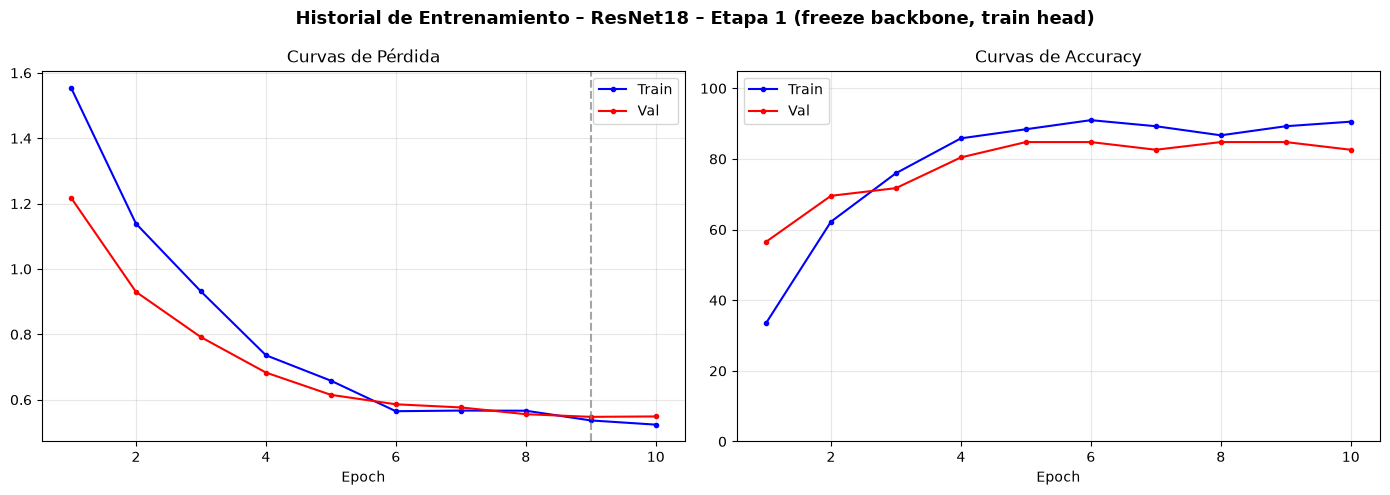

Mejor Val Accuracy: 84.78% (epoch 5)


In [22]:
graficar_historial(historial_head, titulo='ResNet18 – Etapa 1 (freeze backbone, train head)')


## 5. Etapa 2 — Fine-tuning completo (unfreeze)

In [ ]:
# === Etapa 2: UNFREEZE de TODO el modelo ===
for param in modelo_r18.parameters():
    param.requires_grad = True

# Cargar el mejor checkpoint de la etapa 1 para arrancar desde ahí
ckpt_head = torch.load(CKPT_HEAD, map_location=device)
modelo_r18.load_state_dict(ckpt_head['model_state_dict'])
print(f'Resumiendo desde etapa 1 (epoch {ckpt_head["epoch"]}, val_acc {ckpt_head["val_acc"]:.2%})')

EPOCHS_FT   = 25
LR_FT       = 1e-5     # mucho más bajo para no destruir los features de ImageNet

# Optimizer con TODOS los parámetros (backbone + fc)
optimizer_ft = optim.Adam(modelo_r18.parameters(), lr=LR_FT, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FT)

historial_ft = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_ft = float('inf')
CKPT_FT = './checkpoints/resnet18_ft.pth'

print(f'\n=== Etapa 2: fine-tuning completo (unfreeze, LR={LR_FT}) ===')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS_FT + 1):
    tl, ta = entrenar_epoch(modelo_r18, train_loader_r18, criterion_r18, optimizer_ft, device)
    vl, va = evaluar(modelo_r18, val_loader_r18, criterion_r18, device)
    scheduler_ft.step()
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial_ft[k].append(v)
    marca = ''
    if vl < mejor_ft:
        mejor_ft = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r18.state_dict(),
                    'val_acc':va, 'stage':'finetune'}, CKPT_FT)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')

print(f'\n✅ Etapa 2 completa. Mejor val_acc: {max(historial_ft["val_acc"]):.2%}')


Resumiendo desde etapa 1 (epoch 9, val_acc 84.78%)

=== Etapa 2: fine-tuning completo (unfreeze, LR=1e-05) ===
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     0.5077 |     91.4% |     0.4910 |     84.8% ✅
     2 |     0.4653 |     90.6% |     0.4524 |     89.1% ✅
     3 |     0.4115 |     91.4% |     0.4301 |     89.1% ✅
     4 |     0.3110 |     95.7% |     0.4034 |     91.3% ✅
     5 |     0.3225 |     93.6% |     0.3770 |     91.3% ✅
     6 |     0.2825 |     93.6% |     0.3777 |     93.5%
     7 |     0.2478 |     93.6% |     0.3583 |     93.5% ✅


In [ ]:
graficar_historial(historial_ft, titulo='ResNet18 – Etapa 2 (fine-tuning completo)')


## 6. Comparación: FrutasCNN (baseline) vs ResNet18 (TL)

In [ ]:
historial_r18_full = {
    k: historial_head[k] + historial_ft[k] for k in historial_head
}

comparar = comparar_resultados if 'comparar_resultados' in globals() else None
if comparar is not None:
    comparar_resultados(historial_r, historial_r18_full,
                       label1='FrutasCNN (baseline)',
                       label2='ResNet18 (TL)')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    keys = [('train_loss','Loss Train'),('val_loss','Loss Val'),
            ('train_acc','Acc Train'),('val_acc','Acc Val')]
    for ax, (key, titulo) in zip(axes.flatten(), keys):
        v1 = [x*100 for x in historial_r[key]] if 'acc' in key else historial_r[key]
        v2 = [x*100 for x in historial_r18_full[key]] if 'acc' in key else historial_r18_full[key]
        ax.plot(range(1, len(v1)+1), v1, 'b-o', ms=3, label='FrutasCNN')
        ax.plot(range(1, len(v2)+1), v2, 'r-o', ms=3, label='ResNet18 TL')
        ax.set_title(titulo, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Comparación: baseline vs Transfer Learning', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

best_base = max(historial_r['val_acc'])
best_r18  = max(historial_r18_full['val_acc'])
print(f'\n{"Modelo":<25} {"Best Val Acc":>12}')
print('-'*40)
print(f'{"FrutasCNN (baseline)":<25} {best_base*100:>11.2f}%')
print(f'{"ResNet18 (TL)":<25} {best_r18*100:>11.2f}%')


## 7. 📊 Evaluación final ResNet18 (mejor epoch)

In [ ]:
# Cargar el mejor checkpoint (fine-tuning)
ckpt_final = torch.load(CKPT_FT, map_location=device)
modelo_r18.load_state_dict(ckpt_final['model_state_dict'])
print(f"🏆 Mejor epoch (fine-tuning): {ckpt_final['epoch']} | Val acc: {ckpt_final['val_acc']:.2%}")

print("\n" + "="*60)
print("VALIDACIÓN")
print("="*60)
preds_v, labels_v = obtener_predicciones(modelo_r18, val_loader_r18, device)
graficar_confusion(preds_v, labels_v, class_names_r18,
                   titulo=f'ResNet18 Confusión Val (epoch {ckpt_final["epoch"]})')
graficar_reporte(preds_v, labels_v, class_names_r18)

print("\n" + "="*60)
print("TEST")
print("="*60)
preds_t, labels_t = obtener_predicciones(modelo_r18, test_loader_r18, device)
graficar_confusion(preds_t, labels_t, class_names_r18,
                   titulo=f'ResNet18 Confusión Test (epoch {ckpt_final["epoch"]})')
graficar_reporte(preds_t, labels_t, class_names_r18)

print("\n--- Errores visuales (val) - ResNet18 ---")
visualizar_errores(modelo_r18, val_loader_r18, class_names_r18, device, n=16)


---
# 🏆 Generación del submission para la competencia Kaggle

**Competencia:** UTN-IA 2026: Fruit & Vegetable Classifier  
https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier

Usamos el **mejor modelo ResNet18** (checkpoint del fine-tuning) para predecir las imágenes de test de la competencia y generar el archivo `submission.csv` con el formato requerido:

```
image_id,label
img_0001.jpg,apple
img_0002.jpg,tomato
...
```

Las clases válidas son las 5 del dataset de entrenamiento: `apple`, `banana`, `grapes`, `potato`, `tomato`.


## 1. Descargar el dataset de test de la competencia

In [ ]:
# Descargar el dataset de test de la competencia (usando kaggle CLI)
import zipfile
COMP_DIR = Path('./data/test_competencia')
COMP_DIR.mkdir(parents=True, exist_ok=True)

# Si ya está descargado, saltamos el paso
test_images_dir = COMP_DIR / 'test_images'
if not test_images_dir.exists():
    !kaggle competitions download \
        -c utn-ia-2026-fruit-vegetable-classifier \
        -p {COMP_DIR}

    # Descomprimir
    zip_files = list(COMP_DIR.glob('*.zip'))
    for zf in zip_files:
        print(f'Descomprimiendo {zf.name}...')
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(COMP_DIR)
        zf.unlink()  # borrar el zip para ahorrar espacio
    print('✅ Dataset de test descargado y descomprimido')
else:
    print(f'✅ Dataset de test ya presente en {test_images_dir}')


In [ ]:
# Localizar la carpeta con las imágenes de test
# (la estructura puede variar: test_images/ o una subcarpeta)
candidate_dirs = [
    COMP_DIR / 'test_images',
    COMP_DIR / 'utn-ia-2026-fruit-vegetable-classifier' / 'test_images',
]
for d in candidate_dirs:
    if d.exists():
        test_images_dir = d
        break
else:
    # fallback: buscar la primera carpeta que contenga imágenes
    for p in COMP_DIR.rglob('*'):
        if p.is_dir() and (any(p.glob('*.jpg')) or any(p.glob('*.png'))):
            test_images_dir = p
            break

imagenes_test = sorted([
    p for p in test_images_dir.rglob('*')
    if p.suffix.lower() in ['.jpg', '.jpeg', '.png']
])
print(f'✅ {len(imagenes_test)} imágenes de test encontradas en {test_images_dir}')
print('Primeras 5:', [p.name for p in imagenes_test[:5]])


## 2. Cargar el mejor modelo ResNet18

In [ ]:
# Cargar el mejor checkpoint del fine-tuning de ResNet18
ckpt_final = torch.load(CKPT_FT, map_location=device)
modelo_r18.load_state_dict(ckpt_final['model_state_dict'])
modelo_r18.eval()
print(f'🏆 Modelo cargado: epoch {ckpt_final["epoch"]} | val_acc {ckpt_final["val_acc"]:.2%}')

# Mapeo de índices a nombres de clase (los que aprendió el modelo)
CLASES_MODELO = class_names_r18   # ej: ['apple', 'banana', 'grapes', 'potato', 'tomato']
CLASES_COMP = ['apple', 'banana', 'grapes', 'potato', 'tomato']
print(f'Clases del modelo: {CLASES_MODELO}')


## 3. Función de predicción (con TTA)

In [ ]:
@torch.no_grad()
def predecir_imagen(modelo, img_path, device, use_tta=True):
    """Predice la clase de una imagen. Si use_tta=True, aplica Test-Time Augmentation:
    promedia las predicciones de la imagen original + variaciones (flip H, flip V)."""
    img = cargar_imagen_limpia(img_path)
    predicciones = []

    # Pipeline base (sin aleatoriedad)
    base_t = transforms.Compose([
        transforms.Resize((IMG_SIZE_224, IMG_SIZE_224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_224, std=STD_224),
    ])

    # Lista de transforms a probar (original + variaciones)
    if use_tta:
        transforms_tta = [
            base_t,                                                    # original
            transforms.Compose([transforms.RandomHorizontalFlip(p=1.0),  # flip H
                                transforms.Resize((IMG_SIZE_224, IMG_SIZE_224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=MEAN_224, std=STD_224)]),
            transforms.Compose([transforms.RandomVerticalFlip(p=1.0),    # flip V
                                transforms.Resize((IMG_SIZE_224, IMG_SIZE_224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=MEAN_224, std=STD_224)]),
        ]
    else:
        transforms_tta = [base_t]

    for t in transforms_tta:
        tensor = t(img).unsqueeze(0).to(device)
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            logits = modelo(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        predicciones.append(probs)

    # Promediar las probabilidades
    probs_promedio = np.mean(predicciones, axis=0)
    pred_idx = int(np.argmax(probs_promedio))
    pred_label = CLASES_MODELO[pred_idx]
    return pred_label, probs_promedio


# Test rápido sobre la primera imagen
if imagenes_test:
    label, probs = predecir_imagen(modelo_r18, imagenes_test[0], device, use_tta=True)
    print(f'Primer imagen: {imagenes_test[0].name} -> {label}')
    print(f'Probs: {dict(zip(CLASES_MODELO, np.round(probs, 3)))}')


## 4. Generar el archivo `submission.csv`

In [ ]:
import pandas as pd
from datetime import datetime

# Carpeta para guardar submissions (versionada)
submissions_dir = Path('./submissions')
submissions_dir.mkdir(parents=True, exist_ok=True)

# Nombre versionado con timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
submission_path = submissions_dir / f'submission_resnet18_{timestamp}.csv'

# Predecir todas las imágenes
predicciones = []
print(f'Prediciendo {len(imagenes_test)} imágenes con TTA...')
for i, img_path in enumerate(imagenes_test):
    pred_label, _ = predecir_imagen(modelo_r18, img_path, device, use_tta=True)
    # Normalizar el nombre de la clase (minúsculas, sin espacios)
    pred_label = pred_label.lower().strip()
    # Tomar solo la primera palabra si tiene más (ej: "Apple 1" -> "apple")
    if pred_label not in CLASES_COMP:
        pred_label = pred_label.split()[0].lower()
    image_id = img_path.stem  # sin extensión, ej: "img_00000"
    predicciones.append({'image_id': image_id, 'label': pred_label})
    if (i + 1) % 50 == 0 or (i + 1) == len(imagenes_test):
        print(f'  {i+1}/{len(imagenes_test)} procesadas')

df_sub = pd.DataFrame(predicciones)

# Validar que todas las clases son válidas
clases_invalidas = df_sub[~df_sub['label'].isin(CLASES_COMP)]
if len(clases_invalidas) > 0:
    print(f'⚠️  {len(clases_invalidas)} predicciones con clases inválidas:')
    print(clases_invalidas)
else:
    print(f'✅ Todas las {len(df_sub)} predicciones tienen clases válidas')

# Guardar
df_sub.to_csv(submission_path, index=False)
print(f'\n📁 Submission guardado en: {submission_path}')
print(f'   Tamaño: {len(df_sub)} filas')

# Mostrar distribución y preview
print(f'\nDistribución de predicciones:')
print(df_sub['label'].value_counts().sort_index())
print(f'\nPrimeras 10 filas:')
print(df_sub.head(10))


## 5. Validación final del formato

In [ ]:
# Validar el formato del CSV
print('=== Validación del submission ===')
print(f'1. Columnas: {list(df_sub.columns)} (esperado: [image_id, label])')
print(f'2. Filas: {len(df_sub)}')
print(f'3. Nulos: {df_sub.isnull().sum().sum()}')
print(f'4. Clases únicas: {sorted(df_sub["label"].unique())}')
print(f'5. Clases esperadas: {CLASES_COMP}')
matches = set(df_sub['label'].unique()) == set(CLASES_COMP)
print(f'6. Match exacto: {"✅ SÍ" if matches else "❌ NO"}')

# Asegurar formato sin índice
df_sub.to_csv(submission_path, index=False)

# Mostrar las primeras líneas del archivo tal cual se sube
print(f'\n=== Primeras 5 líneas del archivo {submission_path.name} ===')
with open(submission_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(line.rstrip())
